In [48]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from fontTools.unicodedata import block

%matplotlib inline

In [49]:
words = open('data/name.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [50]:
len(words)

32033

In [51]:
chars = sorted(set(''.join(words)))
stoi = {c: i+1 for i,c in enumerate(chars)}
stoi['.'] = 0
itos = {i: c for c, i in stoi.items()}

In [52]:
block_size = 5
X, Y = [], []
for word in words:
    context = [0] * block_size
    for c in word + '.':
        X.append(context)
        ix = stoi[c]
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [74]:
number_embeddings = 10
hidden_layer_neurons = 200
vocab_size = 27

C = torch.randn((vocab_size,number_embeddings))
W1 = torch.randn((number_embeddings * block_size,hidden_layer_neurons))
b1 = torch.randn(hidden_layer_neurons)
W2 = torch.randn((hidden_layer_neurons, vocab_size))
b2 = torch.randn(vocab_size)

paramerter = [C, W1, b1, W2, b2]
for p in paramerter:
    p.requires_grad = True

In [75]:
batch_size = 64
maximum_iterations = 20000

losses = []
for i in range(maximum_iterations):
    lr = 0.1 if i < maximum_iterations * 0.8 else 0.01
    ix = torch.randint(0, X.shape[0], (batch_size,))
    embedded = C[X[ix]]
    h = torch.tanh(embedded.view(-1, number_embeddings * block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    losses.append(loss.log10().item())
    if i % 500 == 0:
        print(f'loss={loss.item()}')


    for p in paramerter:
        p.grad = None

    loss.backward()

    for p in paramerter:
        p.data += -lr * p.grad



loss=27.55860710144043
loss=5.518596172332764
loss=3.011498212814331
loss=2.93953800201416
loss=2.8657302856445312
loss=2.657428026199341
loss=2.394320487976074
loss=2.7889504432678223
loss=2.7823681831359863
loss=2.5032362937927246
loss=2.4915378093719482
loss=2.3364362716674805
loss=2.566652297973633
loss=2.329102039337158
loss=2.673656463623047
loss=2.533106565475464
loss=2.2667934894561768
loss=2.4872426986694336
loss=2.189568042755127
loss=2.372041702270508
loss=2.287191390991211
loss=2.287046194076538
loss=2.3360841274261475
loss=2.419548988342285
loss=2.72762393951416
loss=2.562258243560791
loss=2.7495737075805664
loss=2.4785244464874268
loss=2.5695950984954834
loss=2.262268304824829
loss=2.5315401554107666
loss=2.440389633178711
loss=3.0564680099487305
loss=2.1332390308380127
loss=2.153200626373291
loss=2.4599156379699707
loss=2.225752353668213
loss=2.226055145263672
loss=2.297055959701538
loss=2.3444266319274902


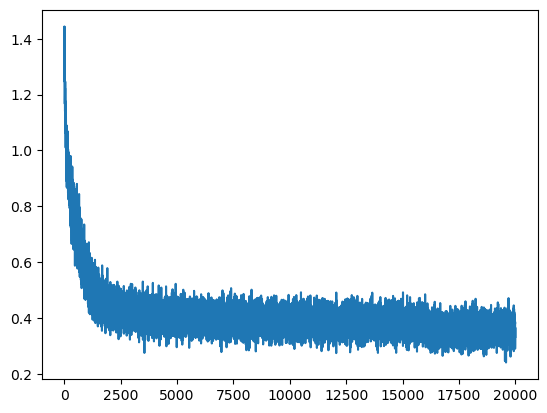

In [76]:
plt.plot(losses)

In [ ]:
g = torch.Generator()
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1,generator=g).item()
        context  = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join([itos[i] for i in out]))

